In [1]:
from src.Elements import Elements
from src.models import create_model 
import torch
import torch.nn as nn

In [2]:

device = "cuda" if torch.cuda.is_available() else "cpu"

model = create_model(model_name="lt_vit", 
                        input_size=4096,
                        patch_size=512,
                        embed_dim=384,
                        num_heads=16,
                        num_outputs=17,
                        num_layers=6,
                        num_lt_layers=1,
                        hidden_dim=256,
                        dropout_rate=0.0,
                        in_channels=1
                    )
model.to(device)

print(model)

print(model(torch.tensor([1.0]*4096 * 64).reshape(64, 1, -1).to(device))[0].shape)
pytorch_total_params = sum(p.numel() for p in model.parameters())
print(pytorch_total_params)

LT_VisionTransformer(
  (patch_embed): Conv1d(1, 384, kernel_size=(512,), stride=(512,), bias=False)
  (dropout): Dropout(p=0.0, inplace=False)
  (standard_blocks): ModuleList(
    (0-4): 5 x TransformerBlock(
      (norm1): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
      (attention): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=384, out_features=384, bias=True)
      )
      (norm2): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
      (mlp): TransformerMLP(
        (feedforward): Sequential(
          (0): LazyLinear(in_features=0, out_features=256, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): LazyLinear(in_features=0, out_features=384, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
    )
  )
  (lt_blocks): ModuleList(
    (0): LT_TransformerBlock(
      (norm1_img): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
      (norm1_lb

In [3]:
from sklearn.model_selection import train_test_split
from src.EvaluationUtils import EvaluationUtils
import numpy as np

X = np.load("data/training_data/artificial/X_regression_20250906_030758.npy")
y = np.load("data/training_data/artificial/y_regression_20250906_030758.npy")

y = y / y.sum(axis=1, keepdims=True)

print(X[0])
print(y[0])
print(np.sum(y[0]))

# y[y>0] = 1
# y[y<=0] = 0
# y = y.astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)
trainloader = EvaluationUtils.create_dataloader(X_train, y_train, device, 160)
testloader = EvaluationUtils.create_dataloader(X_test, y_test, device, 160)


[0. 0. 0. ... 0. 0. 0.]
[0.         0.         0.         0.         0.         0.19869795
 0.         0.         0.10892567 0.         0.         0.
 0.         0.         0.         0.         0.69237638]
1.0


[0.         0.         0.         0.         0.         0.19869795
 0.         0.         0.10892567 0.         0.         0.
 0.         0.         0.         0.         0.69237638]


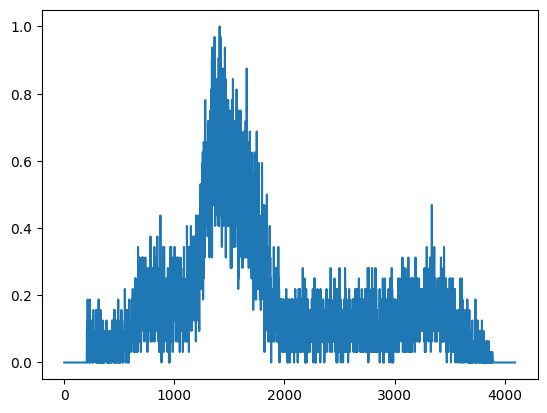

In [4]:
import matplotlib.pyplot as plt

plt.plot(X[0])
print(y[0])

2025-09-08 21:03:25,912 - INFO - Starting training process (mode: supervised, epochs: 50, patience: 5)
2025-09-08 21:03:25,913 - INFO - Threshold for binary prediction: 0.5
2025-09-08 21:03:25,914 - INFO - --- Epoch 1/50 ---
2025-09-08 21:03:26,485 - INFO -   Batch 10/1125, Loss: 0.4644018
2025-09-08 21:03:26,949 - INFO -   Batch 20/1125, Loss: 0.4654537
2025-09-08 21:03:27,308 - INFO -   Batch 30/1125, Loss: 0.4624197
2025-09-08 21:03:27,716 - INFO -   Batch 40/1125, Loss: 0.4693086
2025-09-08 21:03:28,138 - INFO -   Batch 50/1125, Loss: 0.4697995
2025-09-08 21:03:28,529 - INFO -   Batch 60/1125, Loss: 0.4793446
2025-09-08 21:03:28,924 - INFO -   Batch 70/1125, Loss: 0.4713575
2025-09-08 21:03:29,352 - INFO -   Batch 80/1125, Loss: 0.4826245
2025-09-08 21:03:29,770 - INFO -   Batch 90/1125, Loss: 0.4663118
2025-09-08 21:03:30,172 - INFO -   Batch 100/1125, Loss: 0.4662912
2025-09-08 21:03:30,636 - INFO -   Batch 110/1125, Loss: 0.4634373
2025-09-08 21:03:31,094 - INFO -   Batch 120/11

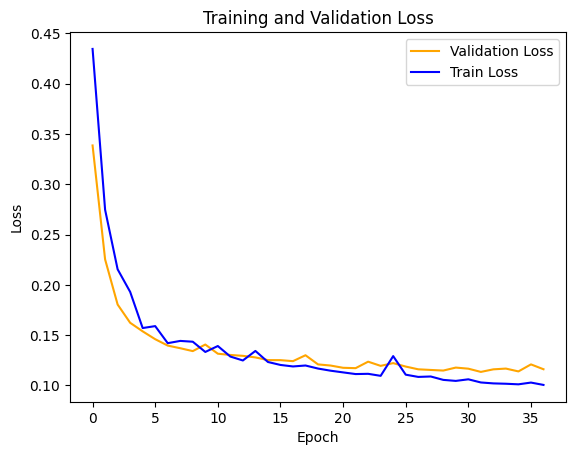

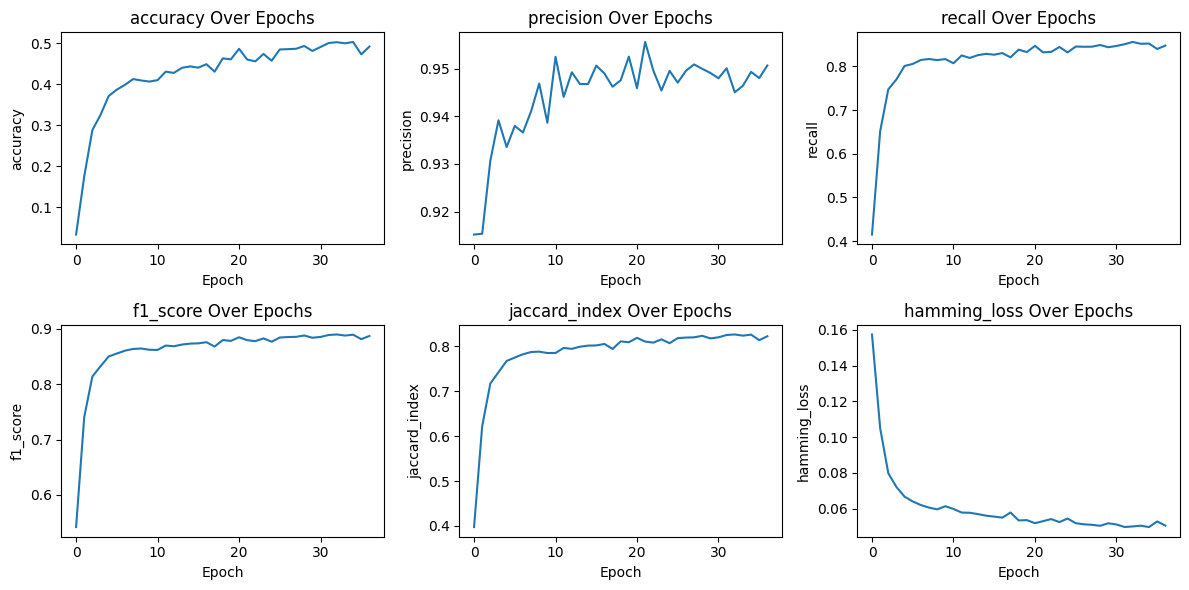

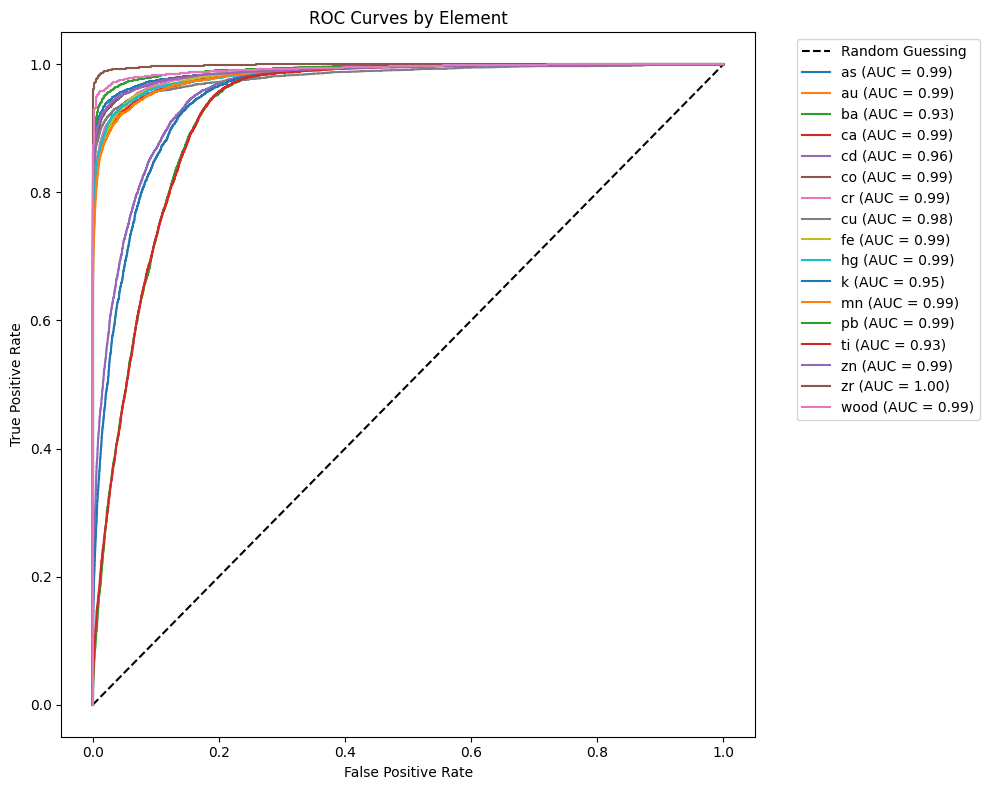

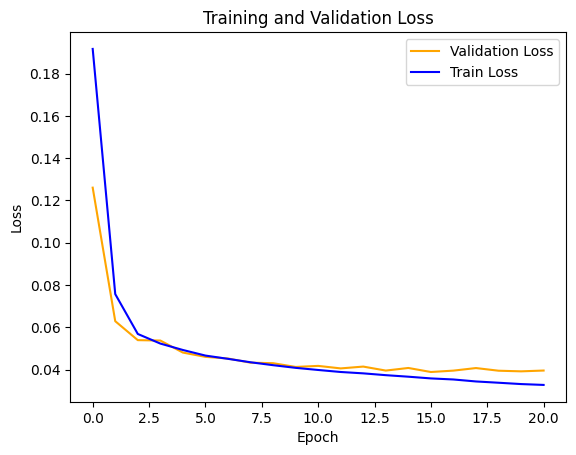

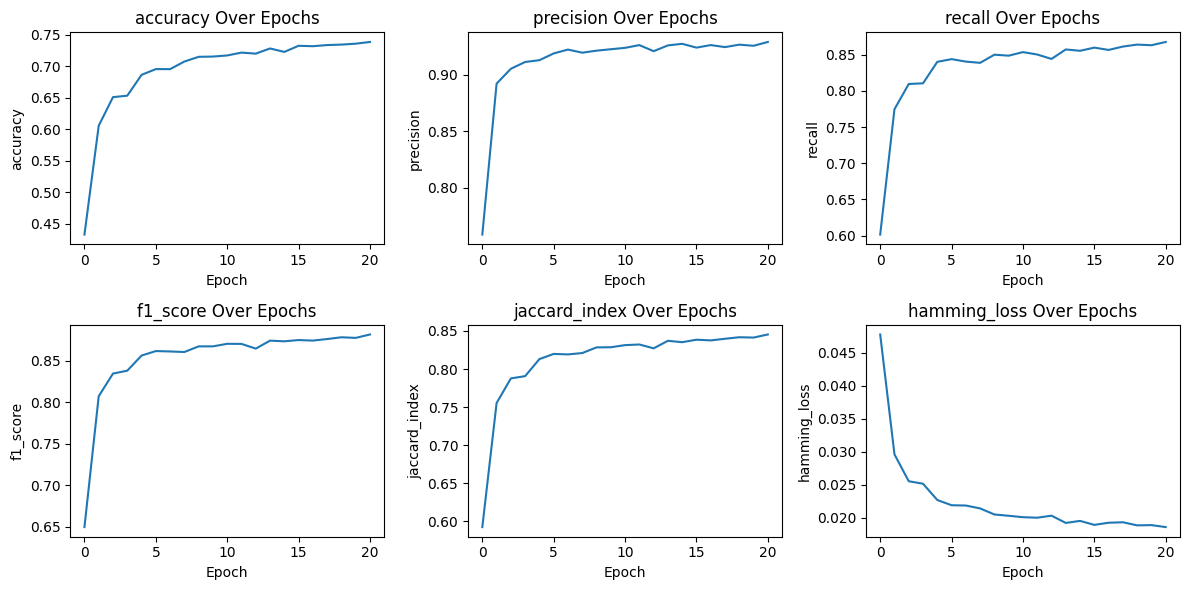

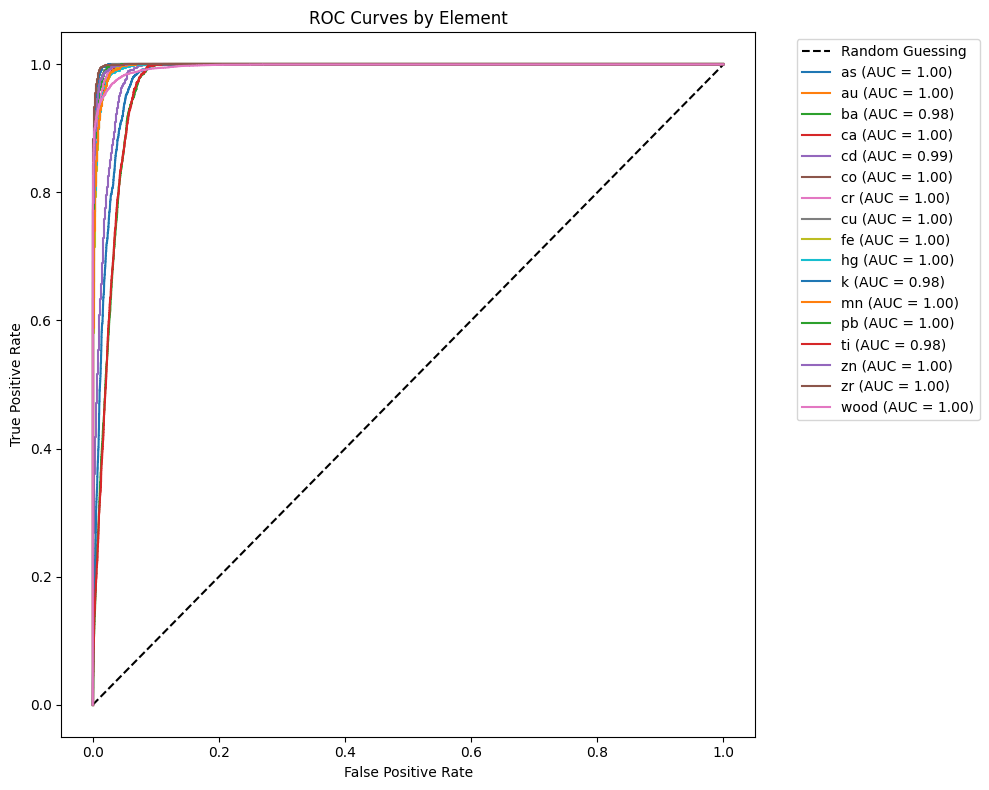

In [9]:
from pathlib import Path
from datetime import datetime 
import gc
from src.EvaluationUtils import EvaluationUtils

all_results = {}
for percent in [1, 25]:
    gc.collect()
    model = create_model(model_name="lt_vit", 
                            input_size=4096,
                            patch_size=256,
                            embed_dim=192,
                            num_heads=12,
                            num_outputs=17,
                            num_layers=6,
                            num_lt_layers=3,
                            hidden_dim=768,
                            dropout_rate=0.0,
                            in_channels=1
                        )

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

    y_train[y_train * 100 > percent] = 1
    y_train[y_train < 1] = 0
    y_train = y_train.astype(int)

    y_test[y_test * 100 > percent] = 1
    y_test[y_test < 1] = 0
    y_test = y_test.astype(int)


    trainloader = EvaluationUtils.create_dataloader(X_train, y_train, device, 200)
    testloader = EvaluationUtils.create_dataloader(X_test, y_test, device, 200)
    model.to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=0.0018269)
    criterion = nn.BCEWithLogitsLoss()
    results = EvaluationUtils.train(model, trainloader, testloader, optimizer=optimizer, criterion=criterion, epochs=50, mode="supervised", patience=5)
    all_results[percent] = results

    MODEL_NAME = model.__class__.__name__
    torch.save(model, Path(f"data/model_weights/classification/{MODEL_NAME}_{percent}--{datetime.now().strftime("%Y-%m-%d--%H-%M-%S")}.pt"))

    model.eval()
    plt.figure()
    plt.plot(results["valid_loss_history"], label="Validation Loss", color="orange")
    plt.plot(results["train_loss_history"], label="Train Loss", color="blue")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training and Validation Loss")
    plt.legend()
    plt.savefig(f"data/plots/classifier/lt_vit_{percent}_loss.png")

    num_metrics = len(results["metric_histories"])
    fig, axes = plt.subplots(2, int(num_metrics / 2), figsize=(12, 6))
    axes = axes.flatten()

    for i, (key, value) in enumerate(results["metric_histories"].items()):
        axes[i].plot(value)
        axes[i].set_title(f"{key} Over Epochs")
        axes[i].set_xlabel("Epoch")
        axes[i].set_ylabel(key)

    plt.tight_layout()
    plt.savefig(f"data/plots/classifier/lt_vit_{percent}_metrics.png")


    aucs, rocs = EvaluationUtils.calculate_roc(model, testloader)

    plt.figure(figsize=(10, 8))
    plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing')
    for element_name in list(Elements.LINES.keys()) + ["wood"]:
        plt.plot(*rocs[element_name], label=f"{element_name} (AUC = {aucs[element_name]:.2f})")

        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title("ROC Curves by Element")
        plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
        plt.tight_layout()
    plt.savefig(f"data/plots/classifier/lt_vit_{percent}_roc_curves.png")



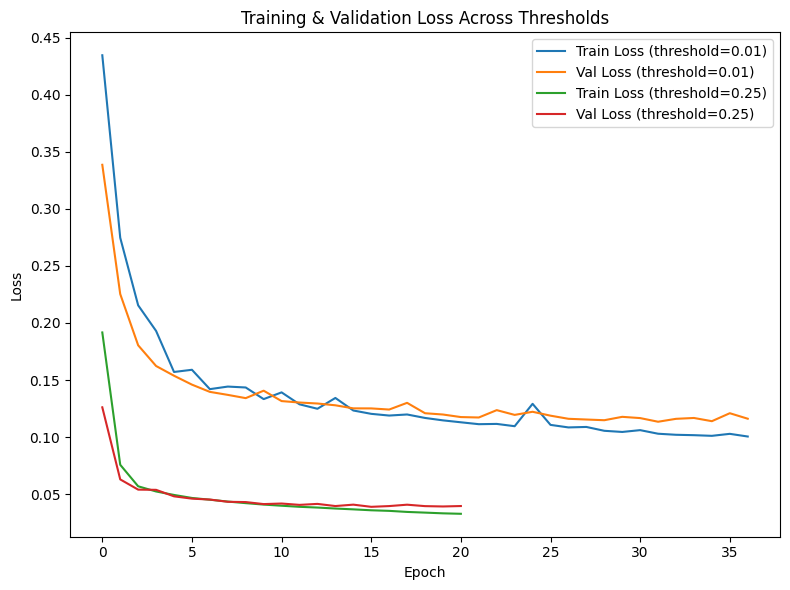

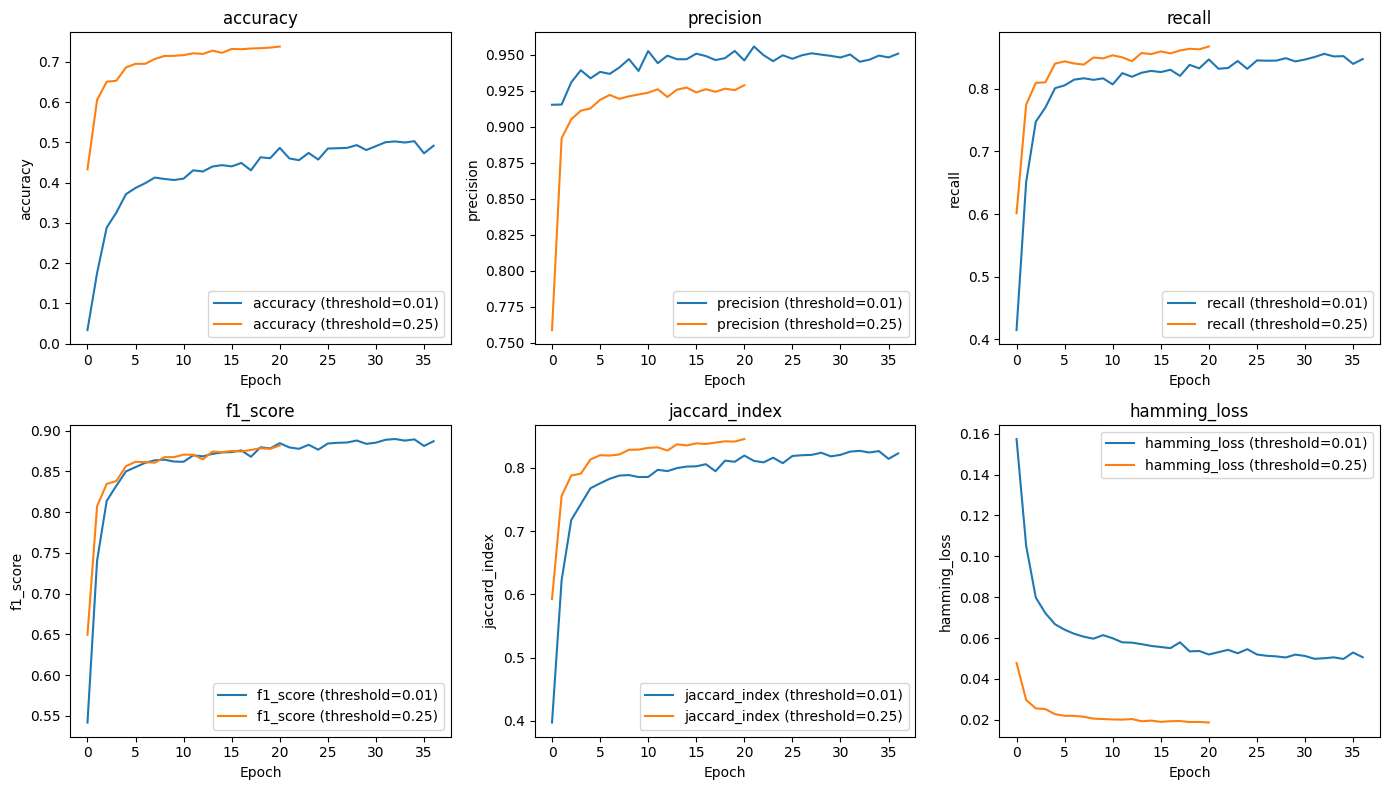

In [12]:
# Plot training vs validation loss across percentages
plt.figure(figsize=(8, 6))
for percent, results in all_results.items():
    plt.plot(results["train_loss_history"], label=f"Train Loss (threshold={percent/100})")
    plt.plot(results["valid_loss_history"], label=f"Val Loss (threshold={percent/100})")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training & Validation Loss Across Thresholds")
plt.legend()
plt.tight_layout()
plt.savefig("data/plots/classifier/lt_vit_all_loss.png")

# Plot metrics across percentages
num_metrics = len(next(iter(all_results.values()))["metric_histories"])
fig, axes = plt.subplots(2, int(num_metrics / 2), figsize=(14, 8))
axes = axes.flatten()

for i, metric in enumerate(next(iter(all_results.values()))["metric_histories"].keys()):
    for percent, results in all_results.items():
        axes[i].plot(results["metric_histories"][metric], label=f"{metric} (threshold={percent/100})")
    axes[i].set_title(metric)
    axes[i].set_xlabel("Epoch")
    axes[i].set_ylabel(metric)
    axes[i].legend()

plt.tight_layout()
plt.savefig("data/plots/classifier/lt_vit_all_metrics.png")

# Compare AUCs across thresholds
# plt.figure(figsize=(10, 8))
# plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing')
# for percent, results in all_results.items():
#     aucs, rocs = EvaluationUtils.calculate_roc(
#         torch.load(Path(f"data/model_weights/classification/lt_vit_{percent}.pt")),  # reload saved model
#         testloader
#     )
#     for element_name in list(Elements.LINES.keys()) + ["wood"]:
#         plt.plot(*rocs[element_name], label=f"{element_name} ({percent}%) AUC={aucs[element_name]:.2f}")

# plt.xlabel("False Positive Rate")
# plt.ylabel("True Positive Rate")
# plt.title("ROC Curves Across Thresholds")
# plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
# plt.tight_layout()
# plt.savefig("data/plots/classifier/lt_vit_all_rocs.png")

/tmp/ipykernel_27093/1323781915.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(Path(model_path)),  # reload saved model
/tmp/ipykernel_27093/1323781915.py:6:

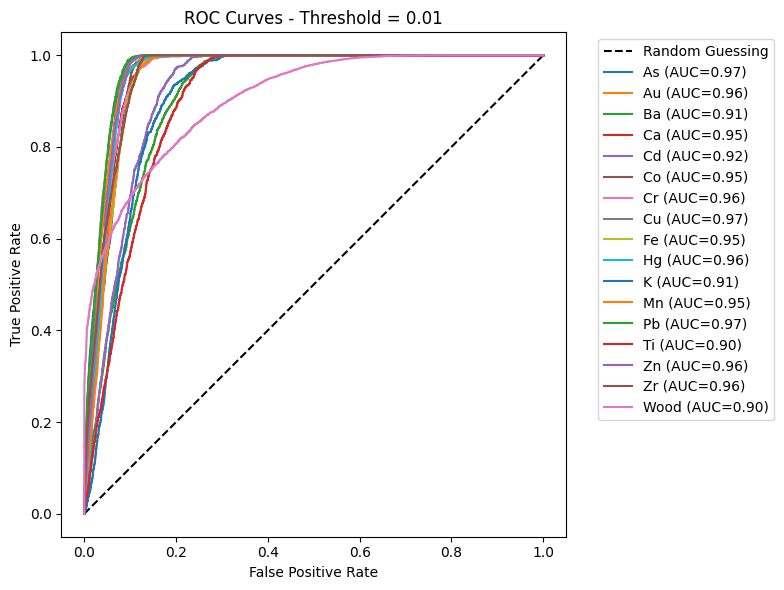

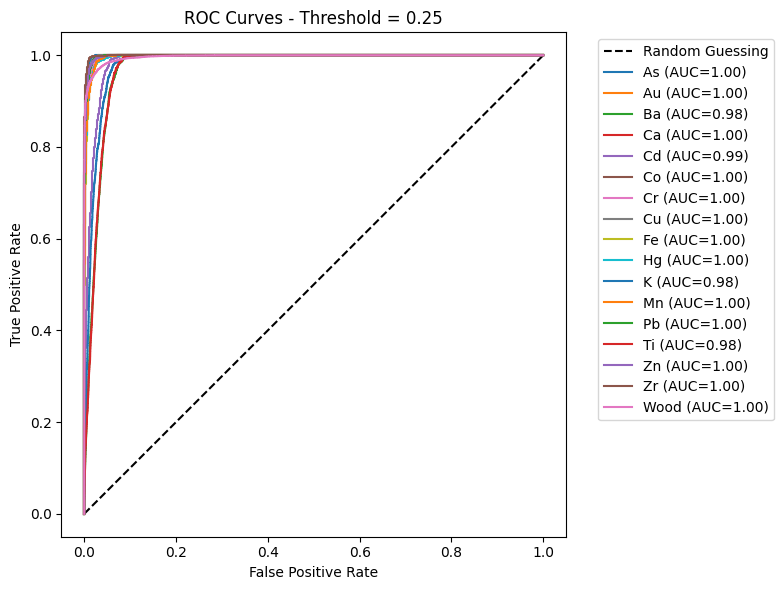

: 

In [ ]:
# Compare AUCs across thresholds
for model_path , (percent, results) in zip(["data/model_weights/classification/LT_VisionTransformer_1--2025-09-08--21-36-43.pt", "data/model_weights/classification/LT_VisionTransformer_25--2025-09-08--21-58-19.pt"], all_results.items()):
    plt.figure(figsize=(8, 6))
    plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing')
    aucs, rocs = EvaluationUtils.calculate_roc(
        torch.load(Path(model_path)),  # reload saved model
        testloader
    )
    for element_name in list(Elements.LINES.keys()) + ["wood"]:
        plt.plot(*rocs[element_name], label=f"{element_name.capitalize()} (AUC={aucs[element_name]:.2f})")

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curves - Threshold = {percent/100}")
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.savefig(f"data/plots/classifier/{Path(model_path).name}.png")

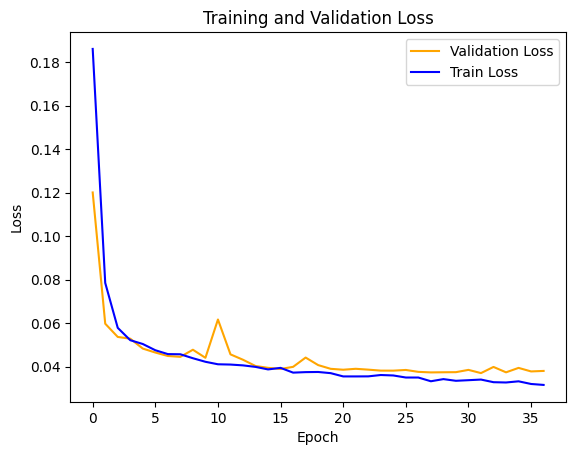

/tmp/ipykernel_27093/4141164600.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[i].legend()


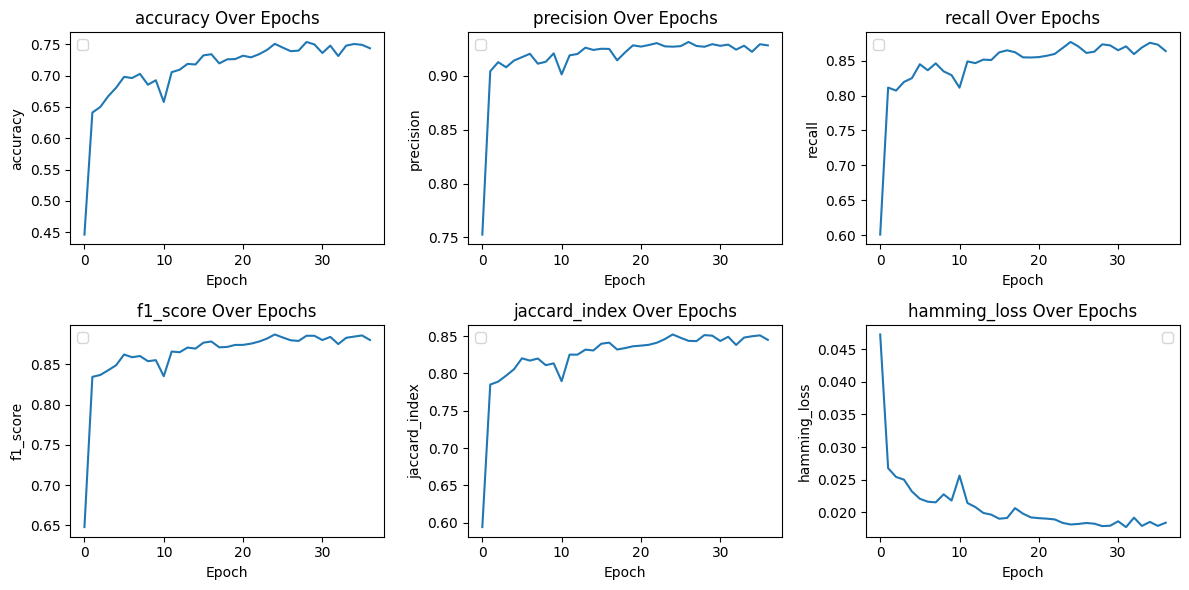

In [6]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(results["valid_loss_history"], label="Validation Loss", color="orange")
plt.plot(results["train_loss_history"], label="Train Loss", color="blue")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

num_metrics = len(results["metric_histories"])
fig, axes = plt.subplots(2, int(num_metrics / 2), figsize=(12, 6))
axes = axes.flatten()

for i, (key, value) in enumerate(results["metric_histories"].items()):
    axes[i].plot(value)
    axes[i].set_title(f"{key} Over Epochs")
    axes[i].set_xlabel("Epoch")
    axes[i].set_ylabel(key)
    axes[i].legend()

plt.tight_layout()

#     print(f"{key}: {value}")

# epochs = range(1, len(metrics[]) + 1)

# fig, axs = plt.subplots(3, 3, figsize=(15, 10))

# axs[0, 0].plot(epochs, train_history, label="Train Loss", color="blue")
# axs[0, 0].plot(epochs, valid_history, label="Validation Loss", color="orange")
# axs[0, 0].set_title("Train vs Validation Loss")
# axs[0, 0].set_xlabel("Epochs")
# axs[0, 0].set_ylabel("Loss")
# axs[0, 0].legend()

# #aaaaaaaaaaaaaaaaaaaaasssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssss Plot F1 Scores
# axs[0, 2].plot(f1_scores, label="F1 Score", color="red")
# axs[0, 2].set_title("F1 Score Over Epochs")
# axs[0, 2].set_xlabel("Epochs")
# axs[0, 2].set_ylim(0, 1)
# axs[0, 2].set_ylabel("F1 Score")

# # Plot Accuracy
# axs[1, 0].plot(accuracies, label="Accuracy", color="purple")
# axs[1, 0].set_title("Accuracy Over Epochs")
# axs[1, 0].set_xlabel("Epochs")
# axs[1, 0].set_ylim(0, 1)
# axs[1, 0].set_ylabel("Accuracy")

# # Plot Recall
# axs[1, 1].plot(recalls, label="Recall", color="brown")
# axs[1, 1].set_title("Recall Over Epochs")
# axs[1, 1].set_xlabel("Epochs")
# axs[1, 1].set_ylim(0, 1)
# axs[1, 1].set_ylabel("Recall")

# # Plot Precision
# axs[1, 2].plot(precisions, label="Precision", color="cyan")
# axs[1, 2].set_title("Precision Over Epochs")
# axs[1, 2].set_xlabel("Epochs")
# axs[1, 2].set_ylim(0, 1)
# axs[1, 2].set_ylabel("Precision")

# axs[2, 0].plot(jaccard_indices, label="Jaccard Indices")
# axs[2, 0].set_title("Jaccard Indices Over Epochs")
# axs[2, 0].set_xlabel("Epochs")
# axs[2, 0].set_ylim(0, 1)
# axs[2, 0].set_ylabel("Jaccard Indices")

# axs[2, 1].plot(hamming_losses, label="Hamming Losses")
# axs[2, 1].set_title("Hamming Losses Over Epochs")
# axs[2, 1].set_xlabel("Epochs")
# axs[2, 1].set_ylim(0, 1)
# axs[2, 1].set_ylabel("Hamming Losses")


# # Adjust layout to avoid overlapping
# plt.tight_layout()
# plt.show()


In [7]:
from src.EvaluationUtils import EvaluationUtils
import src.EvaluationUtils
import importlib
importlib.reload(src.EvaluationUtils)

aucs, rocs = src.EvaluationUtils.EvaluationUtils.calculate_roc(model, testloader)

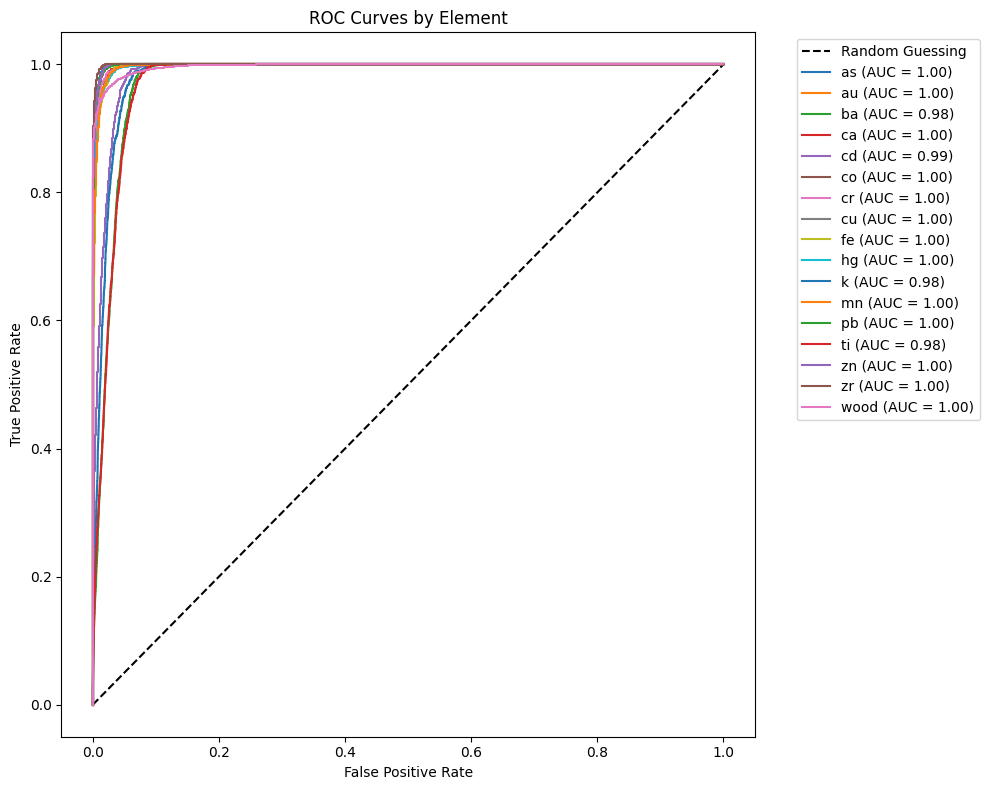

In [8]:


plt.figure(figsize=(10, 8))
plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing')
for element_name in list(Elements.LINES.keys()) + ["wood"]:
    plt.plot(*rocs[element_name], label=f"{element_name} (AUC = {aucs[element_name]:.2f})")

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curves by Element")
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
# plt.savefig("roc_curves.svg")